#### imports

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [11]:
df = pd.read_csv('/kaggle/input/medical-insurance-cost-dataset/insurance.csv')

#### data overview

In [12]:
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [13]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [18]:
df.shape

(1338, 7)

#### data visualization

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

def eda_visuals(df, corr_method='spearman'):
    
    # Select numerical and categorical columns
    numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns

    # Color palette
    palette = sns.color_palette("husl", len(numerical_cols))

    # --Boxplots (Outliers)--
    plt.figure(figsize=(25, 18))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(6, 6, i)
        sns.boxplot(y=df[col], color=palette[i-1])
        plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

    # --Distributions--
    plt.figure(figsize=(25, 15))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(6, 6, i)
        sns.histplot(df[col], kde=True, color=palette[i-1], bins=30)
        plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

    # --Pie Charts for categorical data--
    if len(categorical_cols) > 0:
        plt.figure(figsize=(18, 12))
        for i, col in enumerate(categorical_cols, 1):
            plt.subplot(3, 3, i)
            df[col].value_counts().plot.pie(
                autopct='%1.1f%%',
                startangle=90,
                cmap='tab20'
            )
            plt.title(f'Pie Chart of {col}')
            plt.ylabel('')
        plt.tight_layout()
        plt.show()

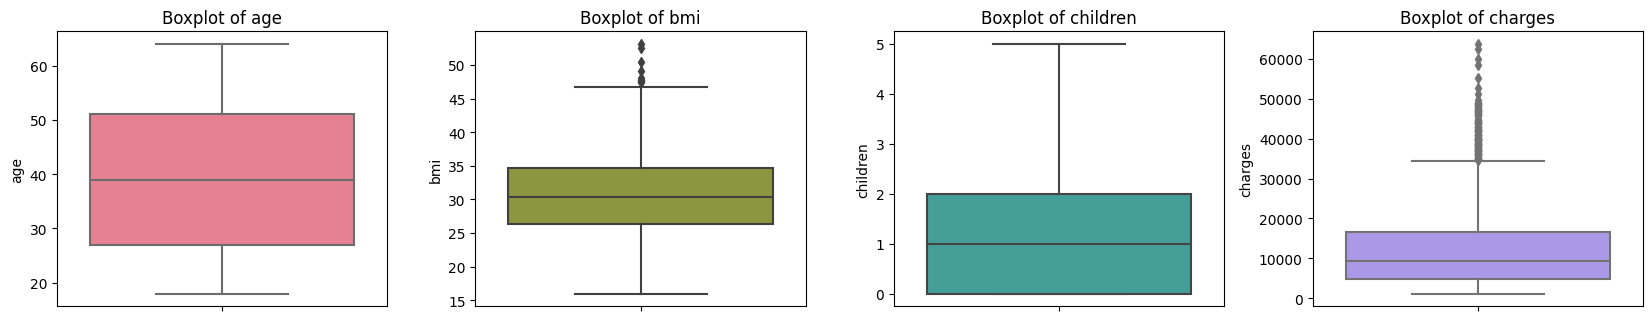

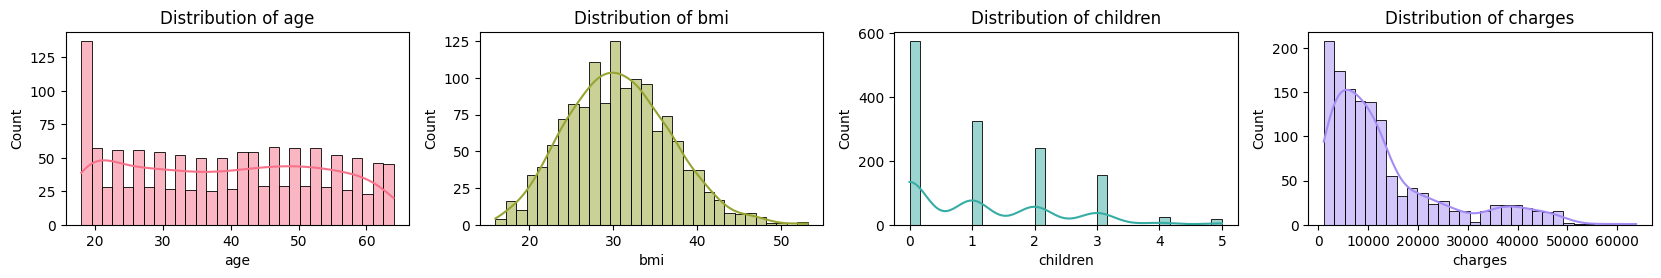

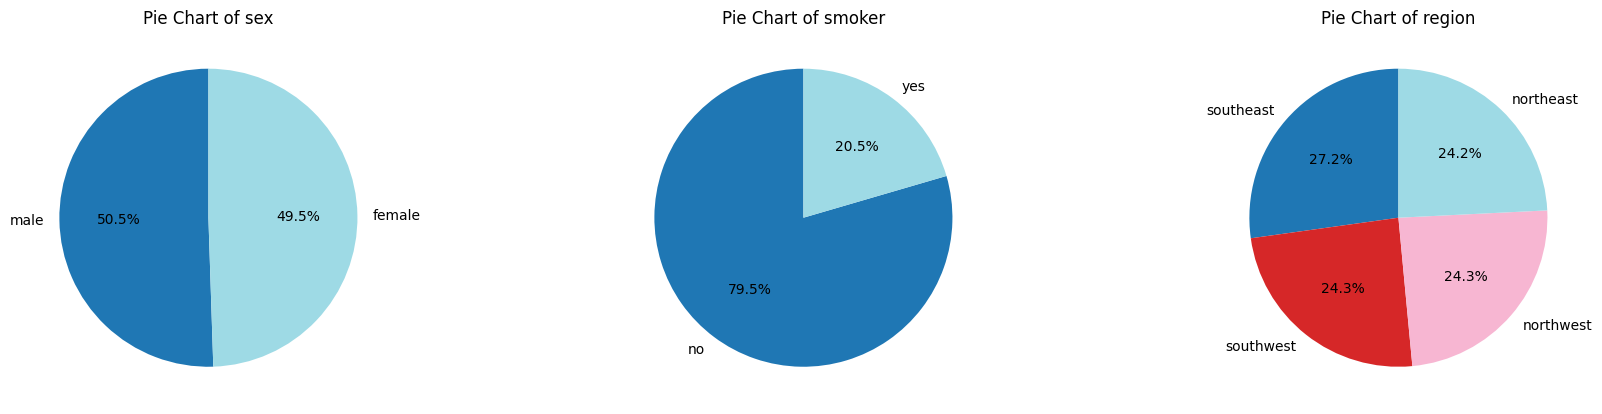

In [15]:
eda_visuals(df)

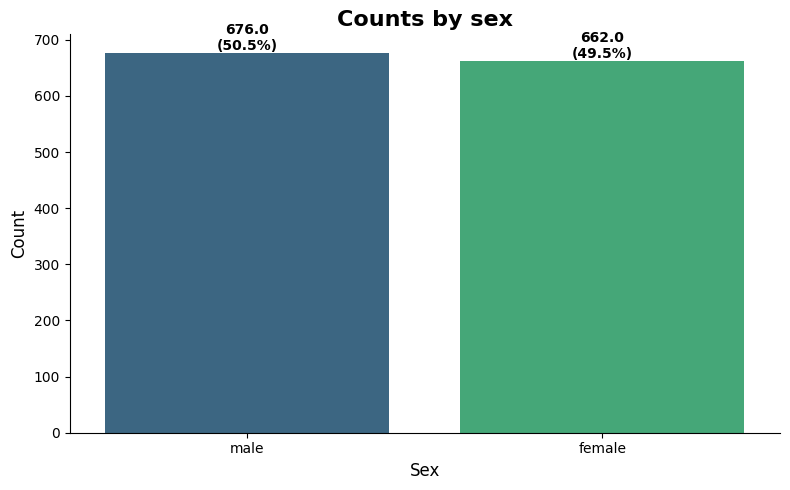

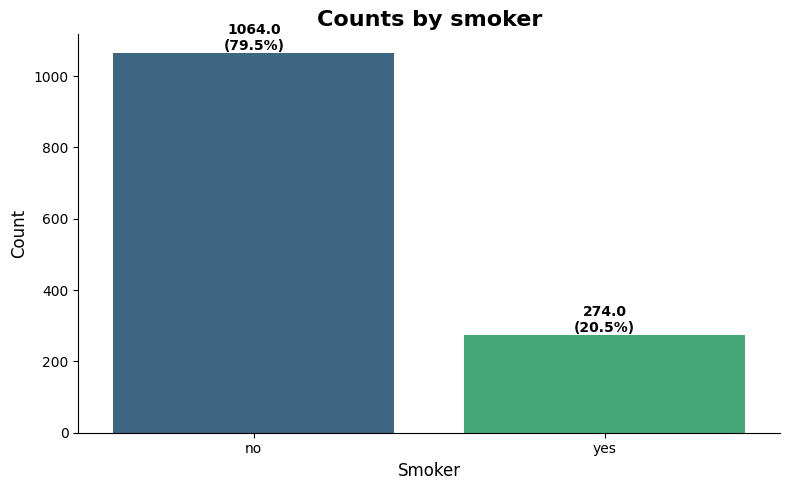

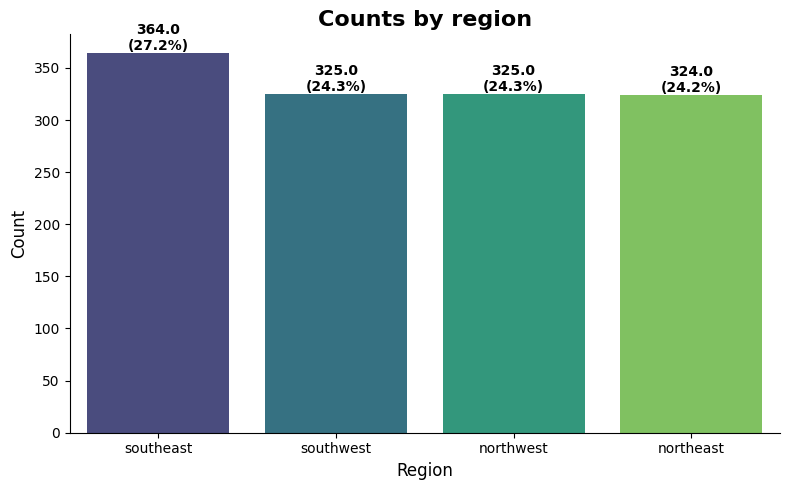

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cat_counts(df:pd.DataFrame, col: str, top_n: int = None):
    
    plt.figure(figsize=(8,5))
    order = df[col].value_counts().index
    
    if top_n:
        order = order[:top_n]
    
    ax = sns.countplot(data=df, x=col, order=order, palette="viridis")
    
    # Title + labels
    plt.title(f"Counts by {col}", fontsize=16, weight="bold")
    plt.xlabel(col.capitalize(), fontsize=12)
    plt.ylabel("Count", fontsize=12)
    
    # Annotate with percentages
    total = len(df)
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f"{height}\n({100*height/total:.1f}%)", 
                    (p.get_x() + p.get_width()/2., height),
                    ha="center", va="bottom", fontsize=10, color="black", weight="bold")
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# Example usage
for col in ["sex", "smoker", "region"]:
    plot_cat_counts(df, col)


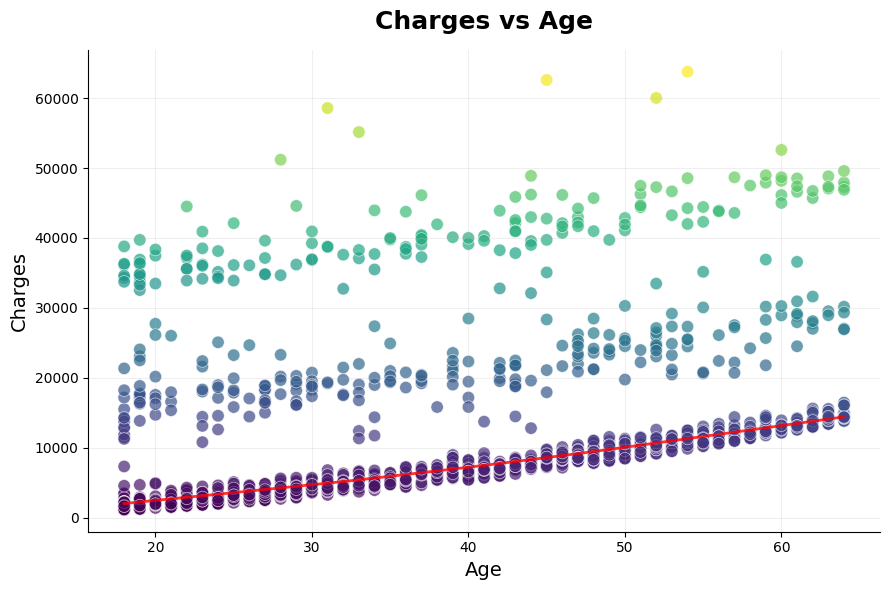

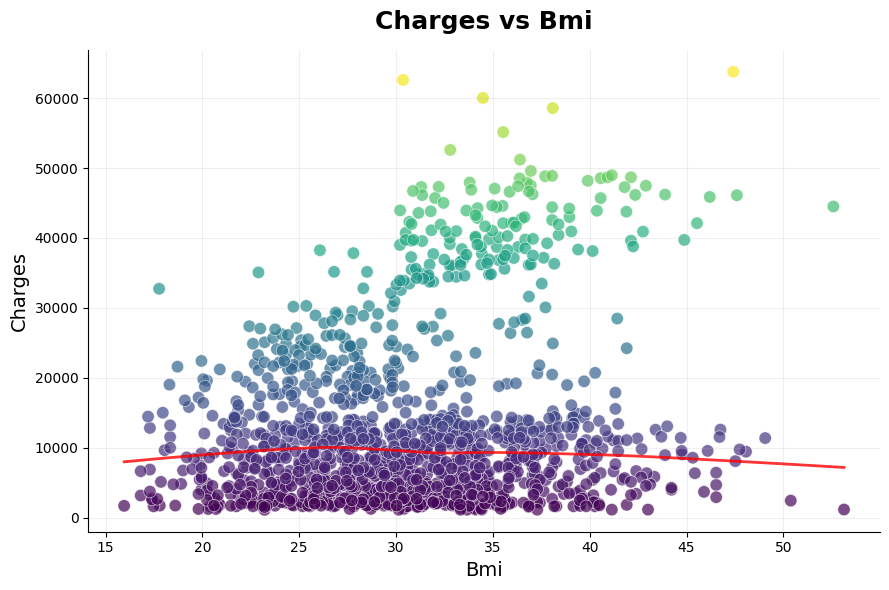

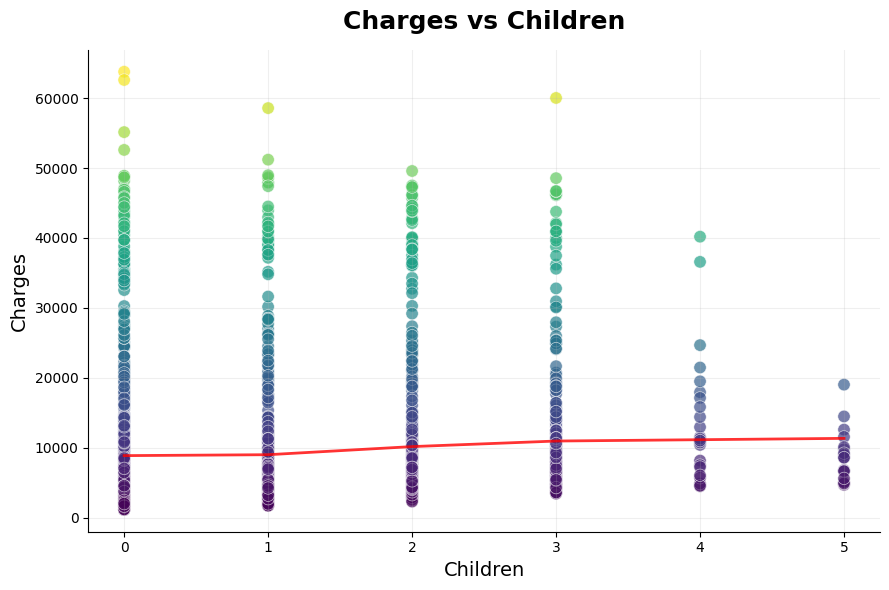

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_scatter(df: pd.DataFrame, x: str, y: str, hue: str = None):
    """
    Attractive scatter plot with gradient colors and smooth trend line.
    
    Parameters:
        df : DataFrame
        x : numeric feature column
        y : target column
        hue : optional categorical column for coloring
    """
    plt.figure(figsize=(9,6))
    
    # Scatter plot with gradient by y if no hue
    if hue:
        ax = sns.scatterplot(
            data=df, x=x, y=y, hue=hue,
            palette="Set2", alpha=0.7, s=80, edgecolor="w", linewidth=0.5
        )
    else:
        ax = sns.scatterplot(
            data=df, x=x, y=y, hue=y,
            palette="viridis", alpha=0.7, s=80, edgecolor="w", linewidth=0.5, legend=False
        )
    
    # Add smooth LOWESS trend line
    sns.regplot(
        data=df, x=x, y=y,
        scatter=False, lowess=True,
        color="red", line_kws={"lw":2, "alpha":0.8}, ax=ax
    )
    
    # Titles and labels
    plt.title(f"{y.capitalize()} vs {x.capitalize()}", fontsize=18, weight="bold", pad=15)
    plt.xlabel(x.capitalize(), fontsize=14)
    plt.ylabel(y.capitalize(), fontsize=14)
    
    # Style
    sns.despine()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

# Example usage
for col in ["age", "bmi", "children"]:
    plot_scatter(df, col, "charges")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004757 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 326
[LightGBM] [Info] Number of data points in the train set: 1070, number of used features: 11
[LightGBM] [Info] Start training from score 13346.089733
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

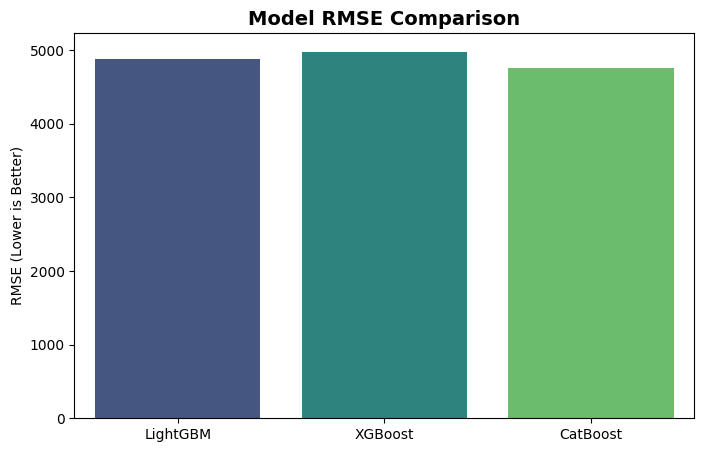

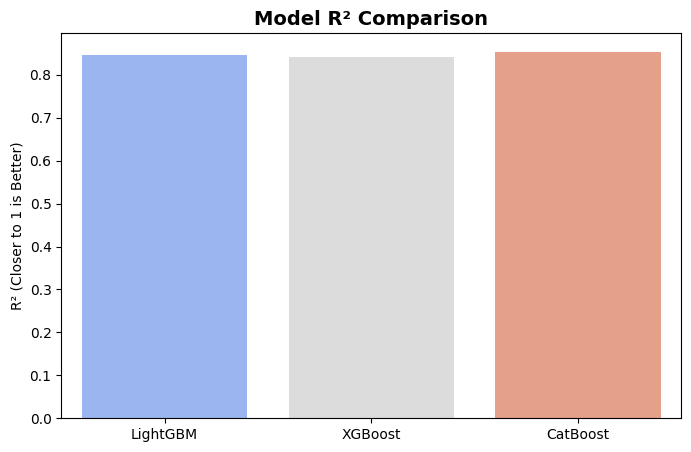


✅ Best Model Selected: CatBoost

Sample Predictions:
Features: {'age': 45, 'sex': 'female', 'bmi': 25.175, 'children': 2, 'smoker': 'no', 'region': 'northeast'} → Predicted Charges: 11287.62
Features: {'age': 36, 'sex': 'female', 'bmi': 30.02, 'children': 0, 'smoker': 'no', 'region': 'northwest'} → Predicted Charges: 8458.82
Features: {'age': 64, 'sex': 'female', 'bmi': 26.885, 'children': 0, 'smoker': 'yes', 'region': 'northwest'} → Predicted Charges: 31436.93
Features: {'age': 46, 'sex': 'male', 'bmi': 25.745, 'children': 3, 'smoker': 'no', 'region': 'northwest'} → Predicted Charges: 10491.01
Features: {'age': 19, 'sex': 'male', 'bmi': 31.92, 'children': 0, 'smoker': 'yes', 'region': 'northwest'} → Predicted Charges: 31945.68


In [25]:
# =============================
# IMPORT LIBRARIES
# =============================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")

# =============================
# TRAIN/TEST SPLIT
# =============================
X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =============================
# PREPROCESSING
# =============================
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# =============================
# DEFINE MODELS
# =============================
models = {
    "LightGBM": lgb.LGBMRegressor(
        n_estimators=1000, learning_rate=0.05,
        max_depth=7, num_leaves=40, random_state=42
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=1000, learning_rate=0.05,
        max_depth=7, subsample=0.8, colsample_bytree=0.8, random_state=42
    ),
    "CatBoost": CatBoostRegressor(
        iterations=1000, learning_rate=0.05,
        depth=7, verbose=0, random_seed=42
    )
}

# =============================
# TRAIN & EVALUATE
# =============================
results = {}
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results[name] = {"RMSE": rmse, "R2": r2}
    fitted_models[name] = pipe

# Convert to DataFrame
results_df = pd.DataFrame(results).T
print("\n📊 Model Performance:")
print(results_df)

# =============================
# VISUALIZE PERFORMANCE
# =============================
plt.figure(figsize=(8,5))
sns.barplot(x=results_df.index, y=results_df["RMSE"], palette="viridis")
plt.title("Model RMSE Comparison", fontsize=14, weight="bold")
plt.ylabel("RMSE (Lower is Better)")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x=results_df.index, y=results_df["R2"], palette="coolwarm")
plt.title("Model R² Comparison", fontsize=14, weight="bold")
plt.ylabel("R² (Closer to 1 is Better)")
plt.show()

# =============================
# FINAL MODEL SELECTION
# =============================
best_model_name = results_df["RMSE"].idxmin()
final_model = fitted_models[best_model_name]
print(f"\n✅ Best Model Selected: {best_model_name}")

# =============================
# PREDICT ON NEW DATA
# =============================
sample = X_test.iloc[:5]
predictions = final_model.predict(sample)

print("\nSample Predictions:")
for i in range(len(sample)):
    print(f"Features: {dict(sample.iloc[i])} → Predicted Charges: {predictions[i]:.2f}")
